<a href="https://colab.research.google.com/github/A-ghori/sklearn/blob/main/Function_Transformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

In [4]:
df = pd.read_csv('/content/Titanic-Dataset.csv', usecols=['Age','Fare','Survived'])
df.head(3)

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250


In [5]:
df.isnull().sum()

,0
Survived,0
Age,177
Fare,0


In [12]:
df['Age'] = df['Age'].fillna(df['Age'].mean())

In [14]:
df.isnull().sum()
df.head(2)

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833


In [20]:
X = df.iloc[:,1:3]
y = df.iloc[:,0]


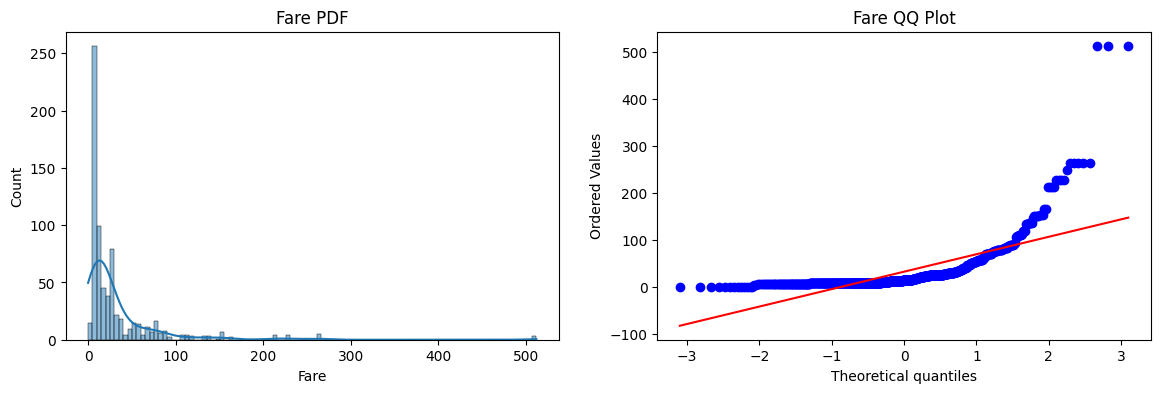

In [28]:
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.2,random_state=42)

plt.figure(figsize=(14,4))
plt.subplot(121)
sns.histplot(X_train['Fare'], kde=True)
plt.title('Fare PDF')
plt.subplot(122)

stats.probplot(X_train['Fare'],dist="norm", plot=plt)
plt.title('Fare QQ Plot')
plt.show()

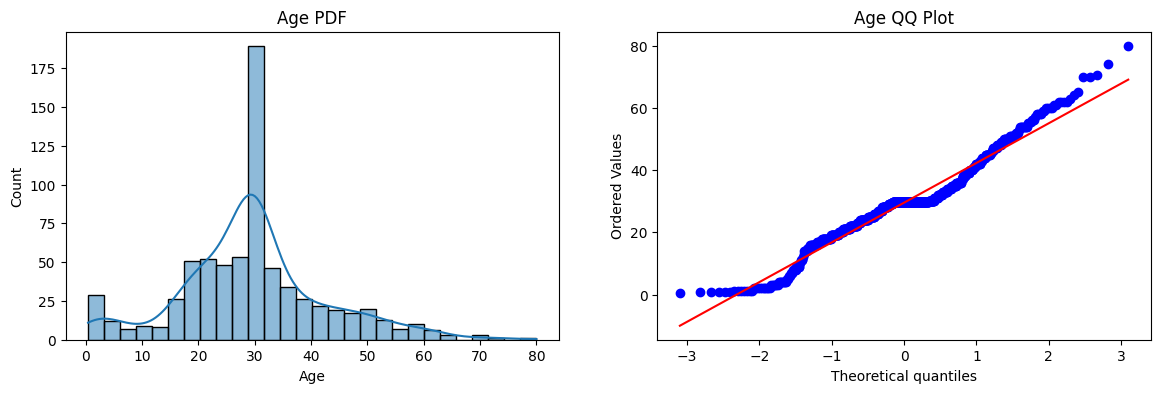

In [31]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.histplot(X_train['Age'], kde=True)
plt.title('Age PDF')
plt.subplot(122)

stats.probplot(X_train['Age'],dist="norm", plot=plt)
plt.title('Age QQ Plot')
plt.show()

In [34]:
## So without using the Monotonic Tranformation or Function Transformer

clf1 = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf1.fit(X_train, y_train)
clf2.fit(X_train, y_train)

y_pred = clf1.predict(X_test)
y_pred1 = clf2.predict(X_test)

print("Accuracy Logistic Regression :",accuracy_score(y_test, y_pred))
print("Accuracy Decision Tree :",accuracy_score(y_test, y_pred1))

Accuracy Logistic Regression : 0.6480446927374302
Accuracy Decision Tree : 0.664804469273743


In [37]:
## So now using Function_Transformer

trf = FunctionTransformer(np.log1p)

X_train_trf = trf.fit_transform(X_train)
X_test_trf = trf.transform(X_test)


clf1 = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf1.fit(X_train_trf, y_train)
clf2.fit(X_train_trf, y_train)

y_pred = clf1.predict(X_test_trf)
y_pred1 = clf2.predict(X_test_trf)

print("Accuracy Logistic Regression :",accuracy_score(y_test, y_pred))
print("Accuracy Decision Tree :",accuracy_score(y_test, y_pred1))


# Using cross validation
X_cross_val_transform = trf.fit_transform(X)

print("LR", np.mean(cross_val_score(clf1, X_cross_val_transform,y,scoring='accuracy',cv=10)))
print("DT", np.mean(cross_val_score(clf2, X_cross_val_transform,y,scoring='accuracy',cv=10)))


Accuracy Logistic Regression : 0.6815642458100558
Accuracy Decision Tree : 0.6759776536312849
LR 0.678027465667915
DT 0.6566292134831461


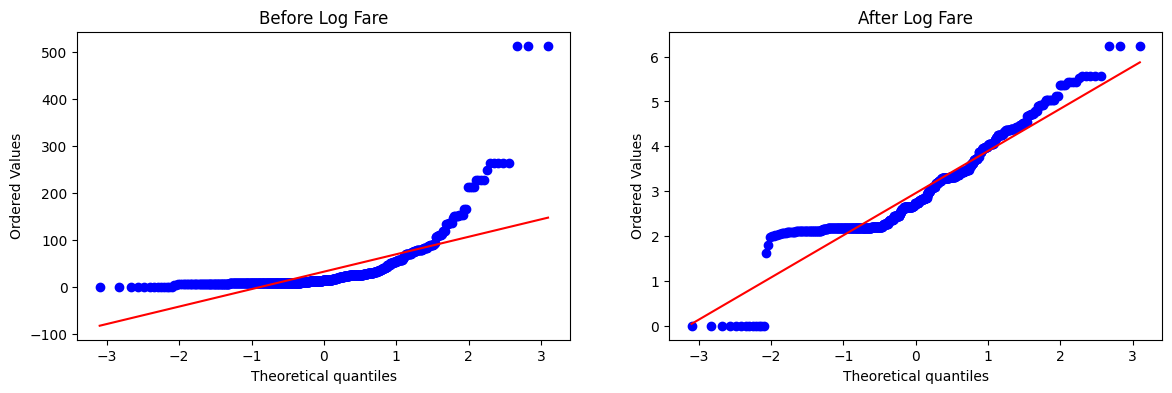

In [40]:
plt.figure(figsize=(14,4))

plt.subplot(121)
stats.probplot(X_train['Fare'],dist='norm', plot=plt)
plt.title('Before Log Fare')

plt.subplot(122)
stats.probplot(X_train_trf['Fare'],dist='norm', plot=plt)
plt.title('After Log Fare')
plt.show()

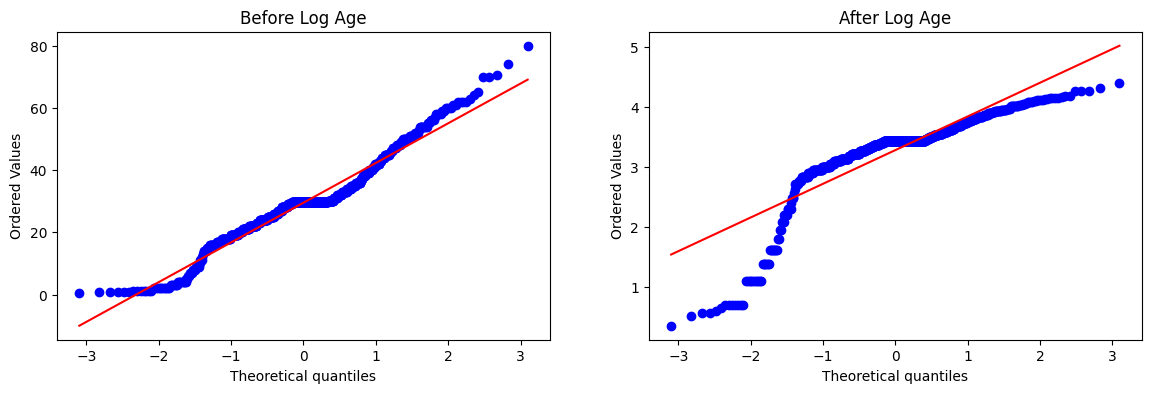

In [53]:
# So here you can clearly see that after using log we get the really bad output
plt.figure(figsize=(14,4))

plt.subplot(121)
stats.probplot(X_train['Age'],dist='norm', plot=plt)
plt.title('Before Log Age')

plt.subplot(122)
stats.probplot(X_train_trf['Age'],dist='norm', plot=plt)
plt.title('After Log Age')
plt.show()

In [46]:
trf1 = ColumnTransformer([('log',FunctionTransformer(np.log1p), ['Fare'])], remainder='passthrough')

X_train_transformed2 = trf1.fit_transform(X_train)
X_test_transformed2 = trf1.transform(X_test)

clf1 = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf1.fit(X_train_transformed2, y_train)
clf2.fit(X_train_transformed2, y_train)

y_pred = clf1.predict(X_test_transformed2)
y_pred1 = clf2.predict(X_test_transformed2)

print("Accuracy Logistic Regression :",accuracy_score(y_test, y_pred))
print("Accuracy Decision Tree :",accuracy_score(y_test, y_pred1))


Accuracy Logistic Regression : 0.6703910614525139
Accuracy Decision Tree : 0.6815642458100558


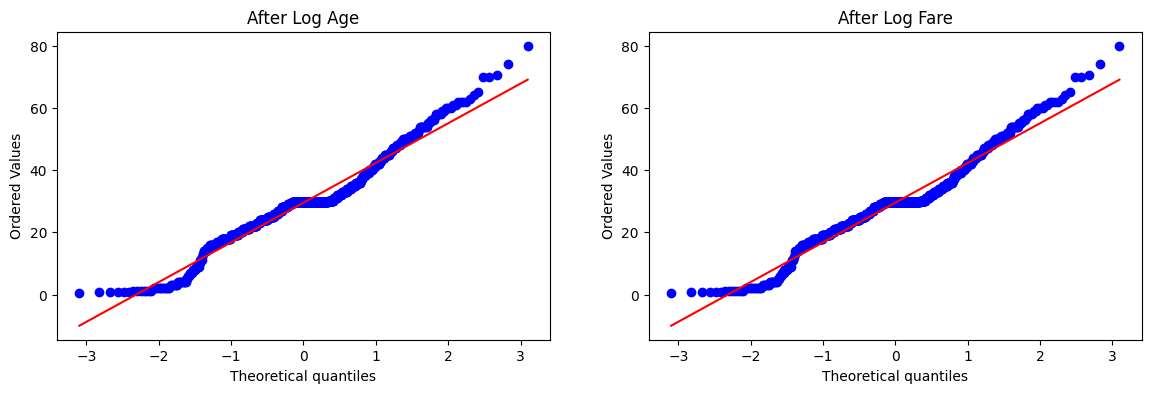

In [51]:
plt.figure(figsize=(14,4))
plt.subplot(121)
stats.probplot(X_train_transformed2[:,1],dist='norm',plot=plt)
plt.title('After Log Age')

plt.subplot(122)
stats.probplot(X_train_transformed2[:,-1],dist='norm',plot=plt)
plt.title('After Log Fare')
plt.show()
